In [34]:
import os as os
import sys
import numpy as np

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# adding folders to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd()  , '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

akshat_lisa_root = os.path.abspath(os.path.join(os.getcwd()  , '..',))
if akshat_lisa_root not in sys.path:
    sys.path.insert(0, akshat_lisa_root)

from scripts.readTdi import readTdi, getTdiPath
from scripts.wosa import wosa
from scripts.psdNoise import n_time_noise_from_psd, n_noise_psds, compute_psd_noise_distribution
from scripts.plot import plot_psd_noise_histogram, plot, plot_orig_and_noise_psds
from scripts.mle import mle_df

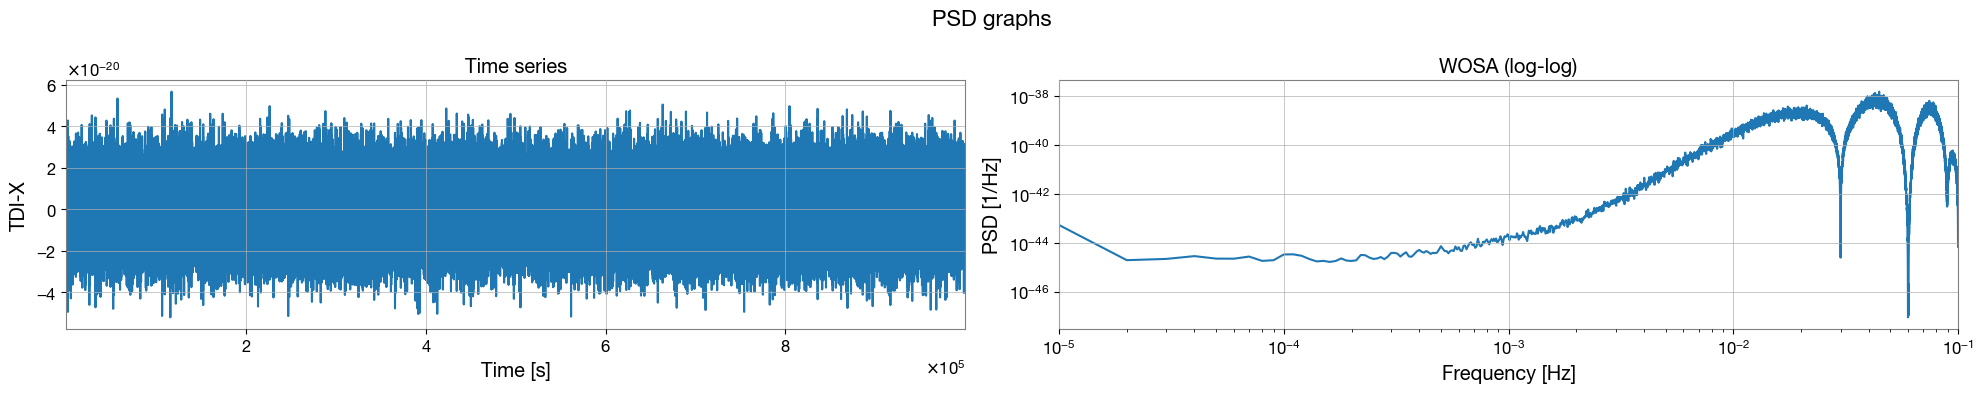

In [35]:
# 1) Read the TDI time series
tdi_path = getTdiPath('vsmall_glitch_long_tdi.h5')
data, fs, t = readTdi(tdi_path)

# 2) Find the PSD of TDI time series
nperseg = 20000
f_orig, orig_psd, _, _ = wosa(
    x=data,
    fs=fs,
    nperseg=nperseg
) 

# Plot the original psd for no reason 
plot(data, t, fs, f_orig, orig_psd,  nperseg, title="TDI-X", bigtitle="PSD graphs")

# 3) generate n time-domain noise realisations such that PSD equals "PSD OF TDI time series "
time_noises = n_time_noise_from_psd(
    orig_psd, 
    fs, 
    nperseg, 
    n=1000,
    seed_offset=0
)

In [49]:
def psdAndEverything(nperseg_noise, noverlap, fraction, df, n_bins=30):
    # 4) Find PSDs of time-domain noise realisations
    f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap= noverlap)

    # 5) Choose a frequency
    psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

    # 6) Plot the histogram
    plot_psd_noise_histogram(
        psd_noise_vals,
        orig_psd_val,
        chosen_f_noise,
        n_bins=n_bins,
        title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
        df=df
    )

In [ ]:
# 4) Find PSDs of time-domain noise realisations
nperseg_noise = 5000
noverlap= nperseg_noise // 2
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap= noverlap)

# 5) Choose a frequency
fraction=0.7
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)

# 6) Plot the histogram
plot_psd_noise_histogram(
    psd_noise_vals,
    orig_psd_val,
    chosen_f_noise,
    n_bins=30,
    title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    df=2*nseg
)

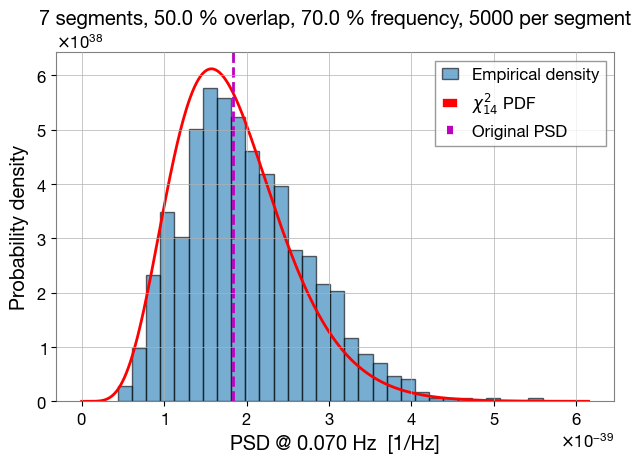

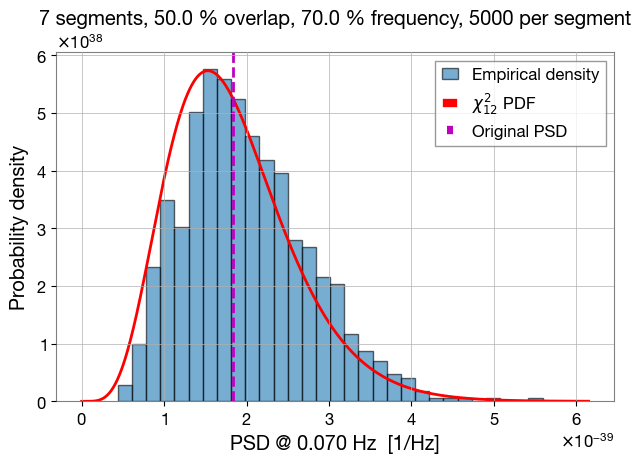

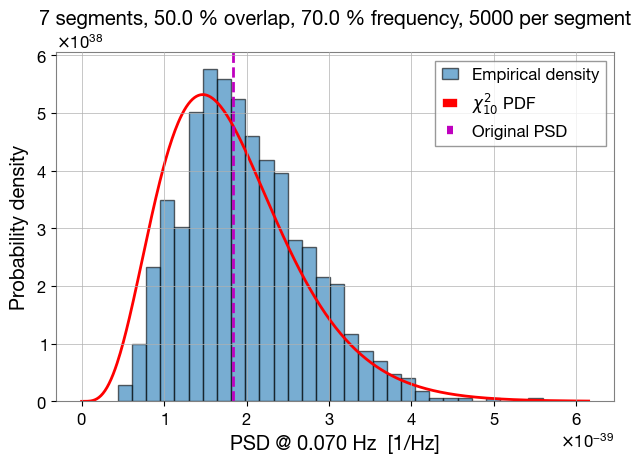

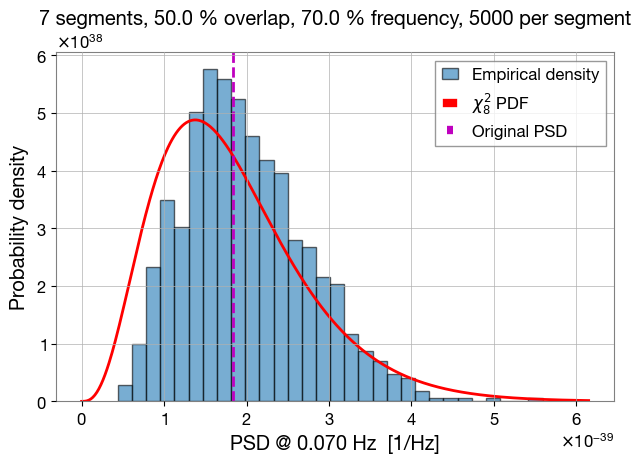

In [64]:
nperseg_noise = 5000
noverlap = nperseg_noise // 2
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=14
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 12
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 10
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 8
)

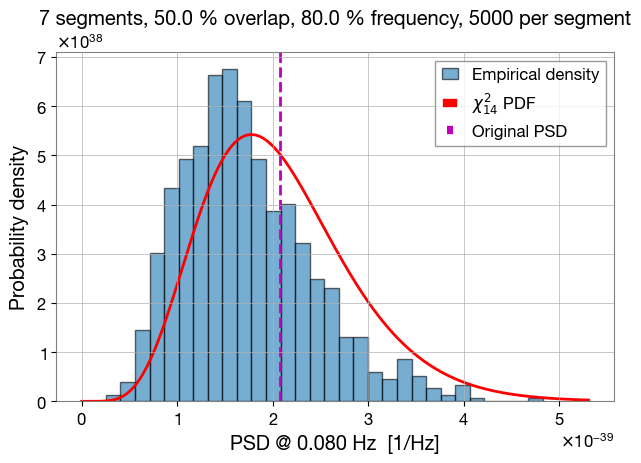

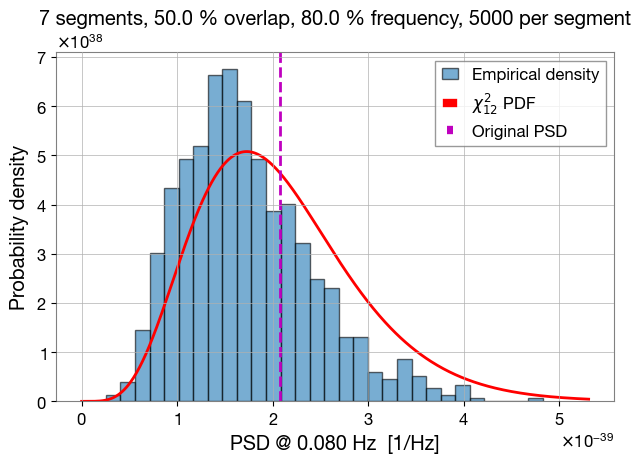

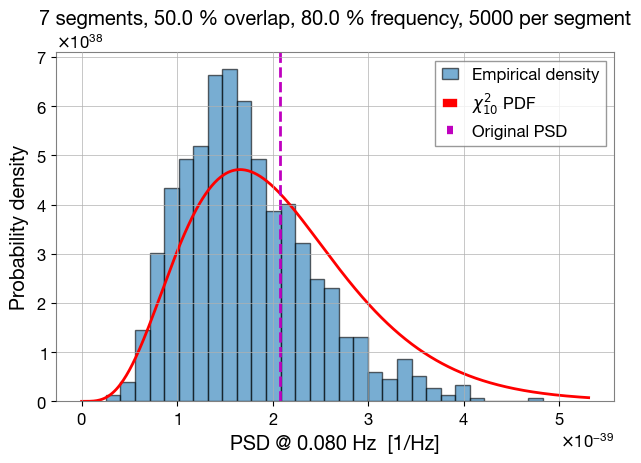

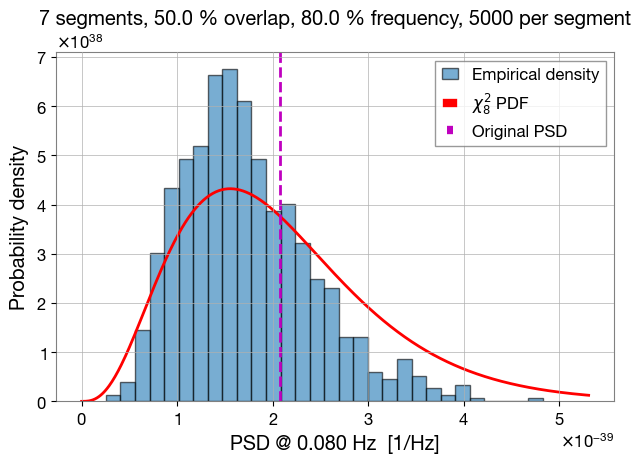

In [63]:
nperseg_noise = 5000
noverlap = nperseg_noise // 2
fraction = 0.8
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=14
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.8, 
    df = 12
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.8, 
    df = 10
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.8, 
    df = 8
)

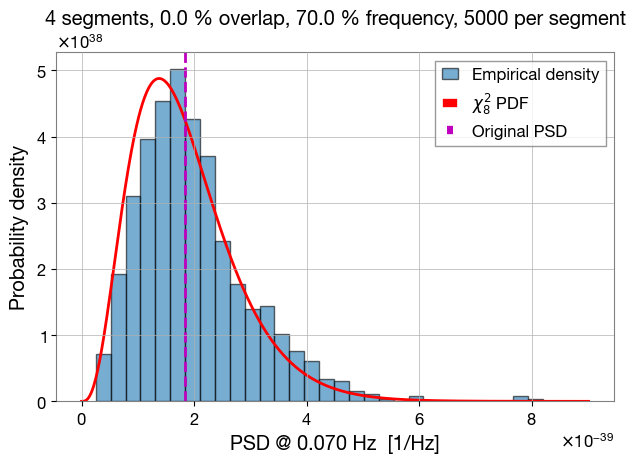

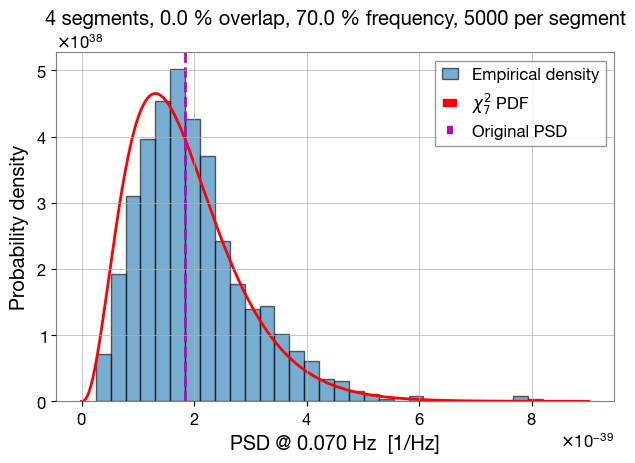

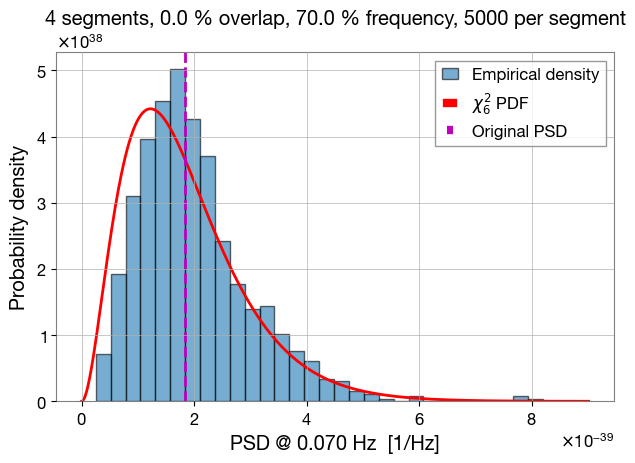

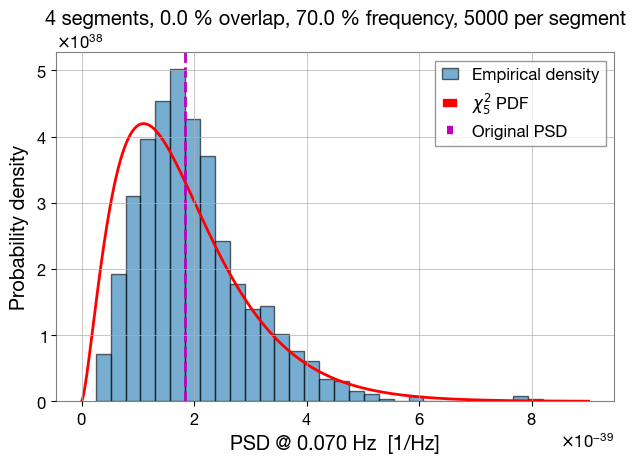

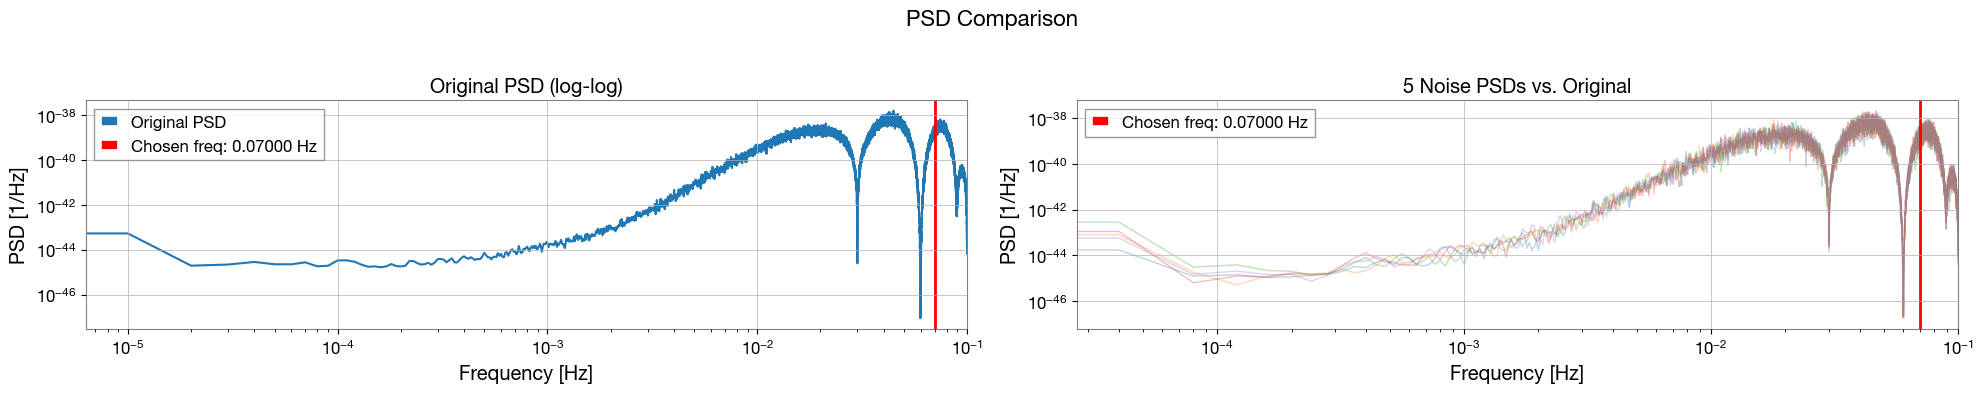

In [58]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=2*nseg
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.7, 
    df = 7,
    n_bins = 30
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.7, 
    df = 6,
    n_bins = 30
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.7, 
    df = 5,
    n_bins = 30
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

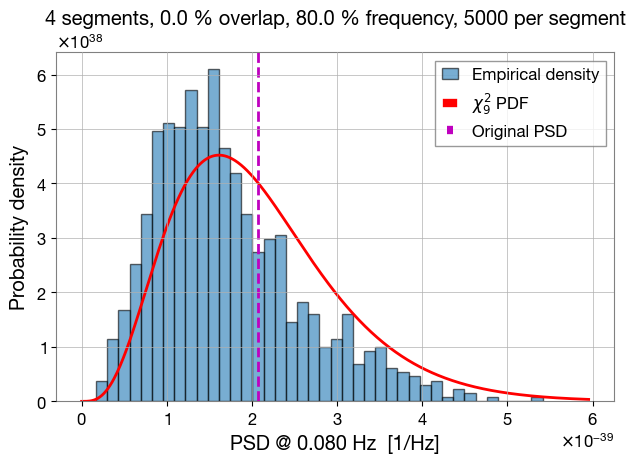

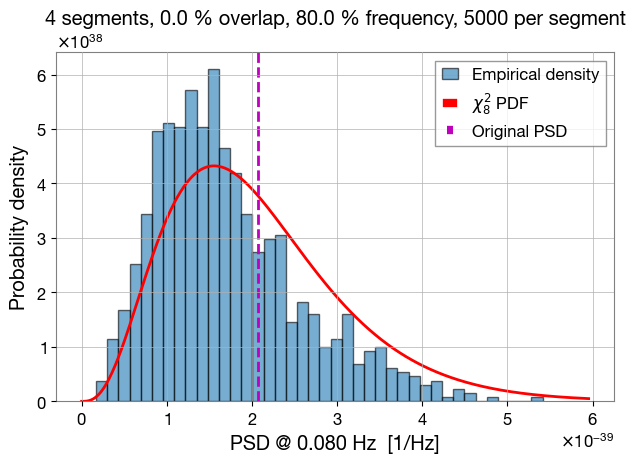

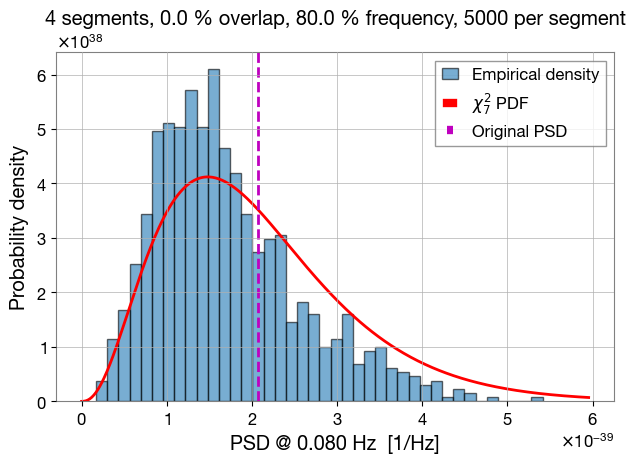

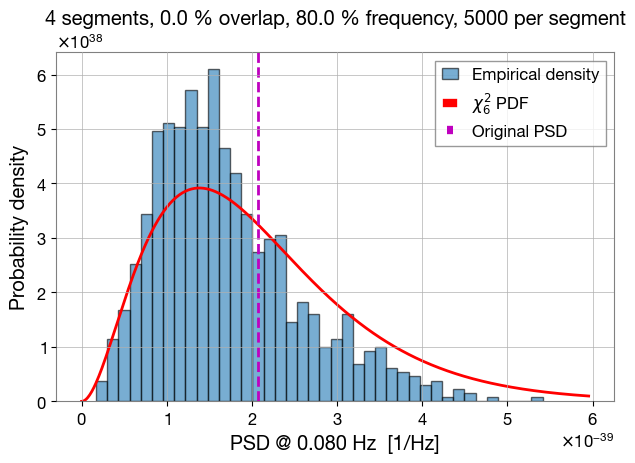

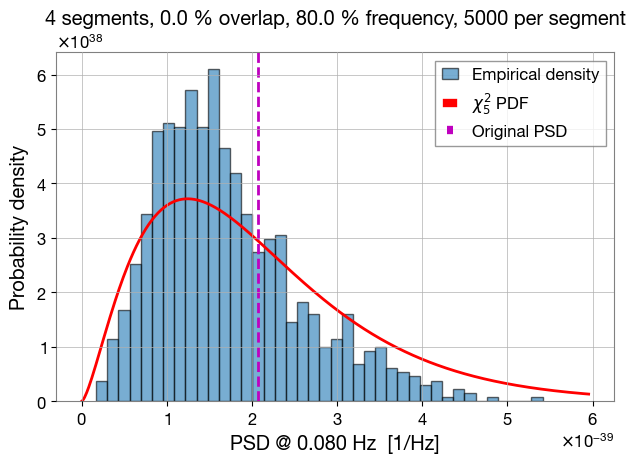

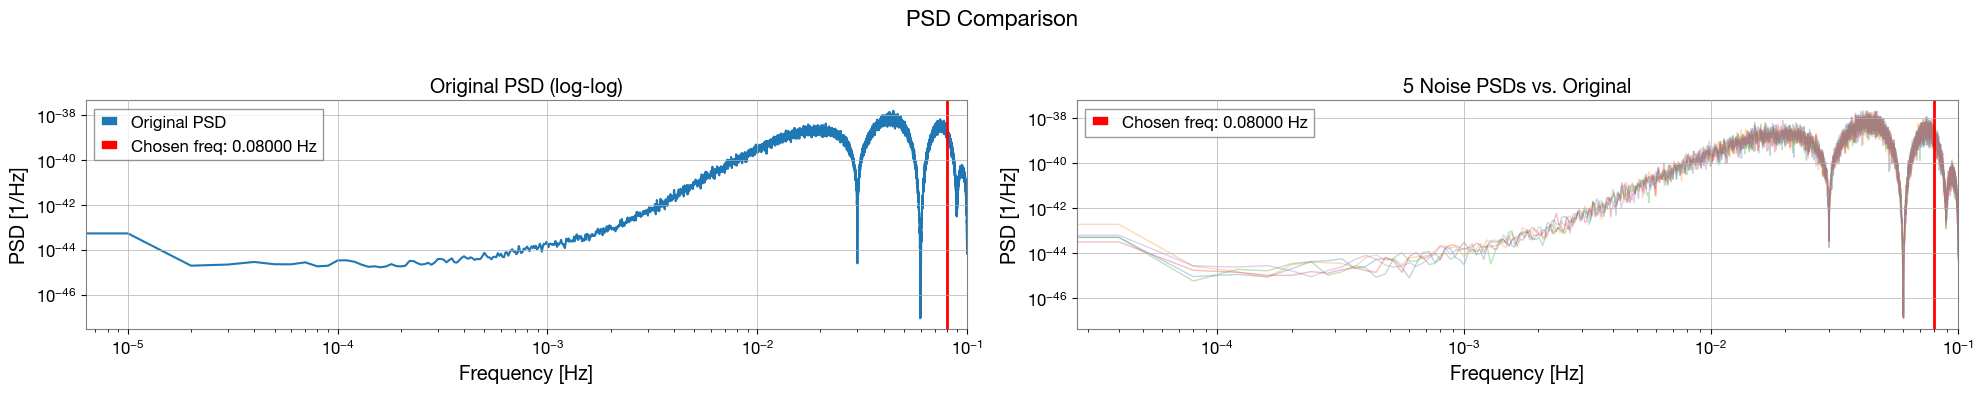

In [57]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.8
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=9
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.8, 
    df = 8,
    n_bins = 40
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.8, 
    df = 7,
    n_bins = 40
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.8, 
    df = 6,
    n_bins = 40
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = 0.8, 
    df = 5,
    n_bins = 40
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

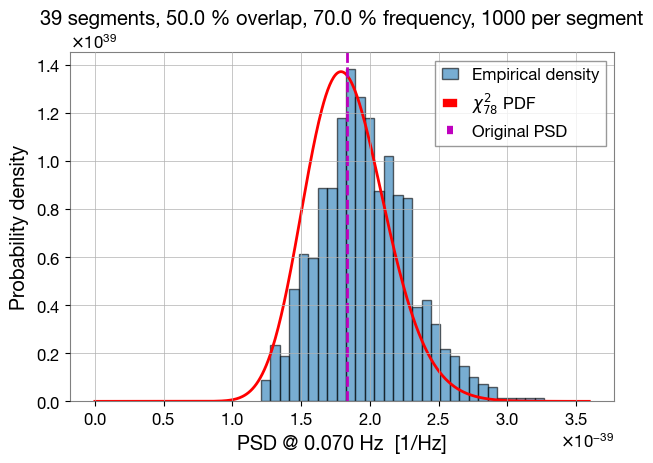

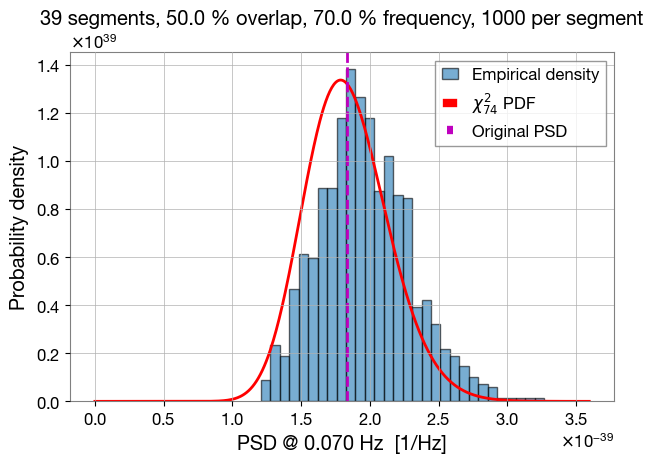

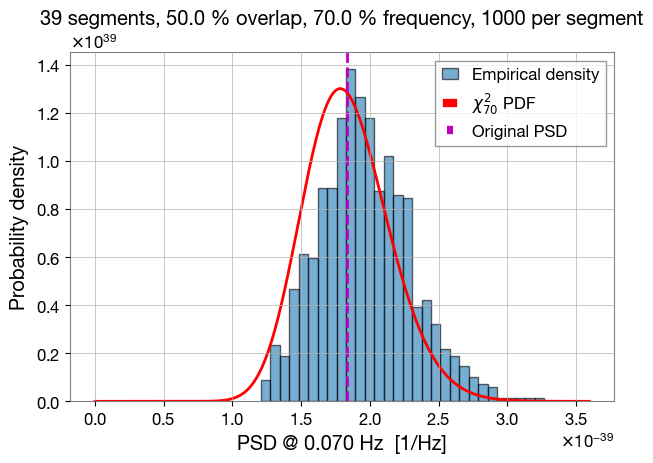

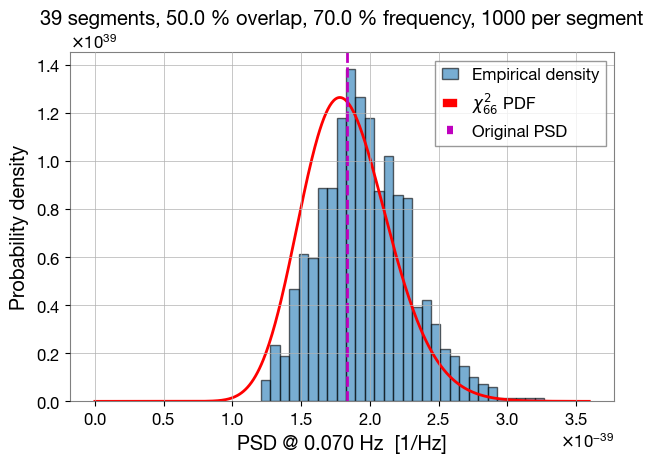

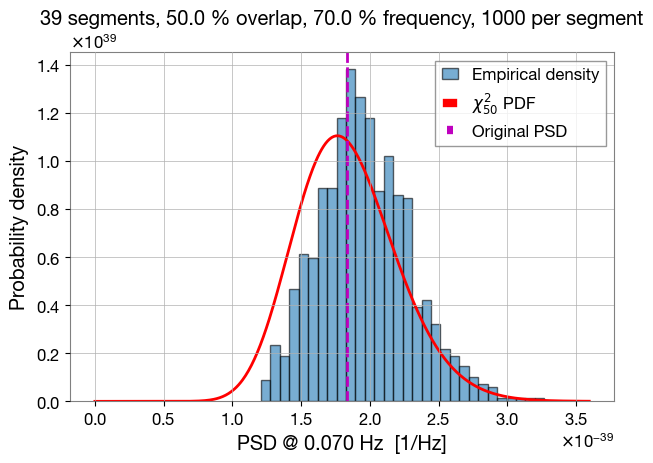

In [68]:
nperseg_noise = 1000
noverlap = nperseg_noise // 2
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df= 2*nseg
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 74
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 70
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 66
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = nperseg_noise // 2, 
    fraction = 0.7, 
    df = 50
)

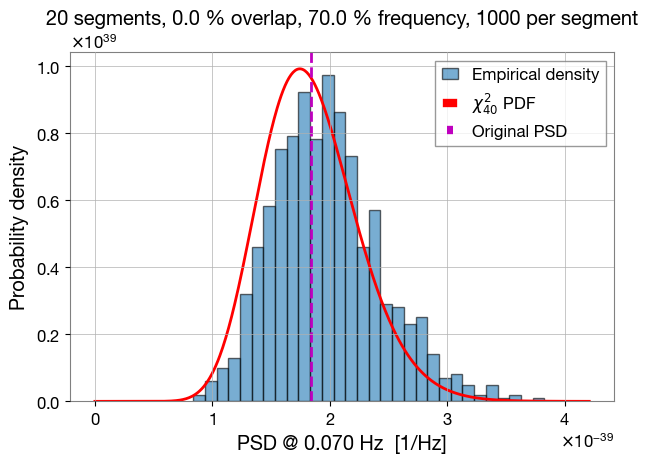

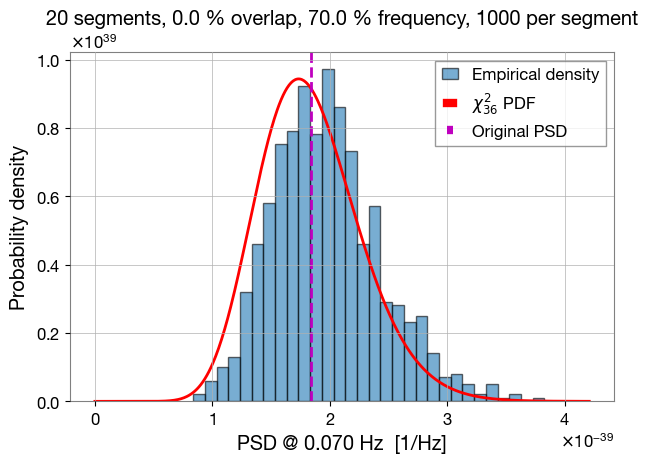

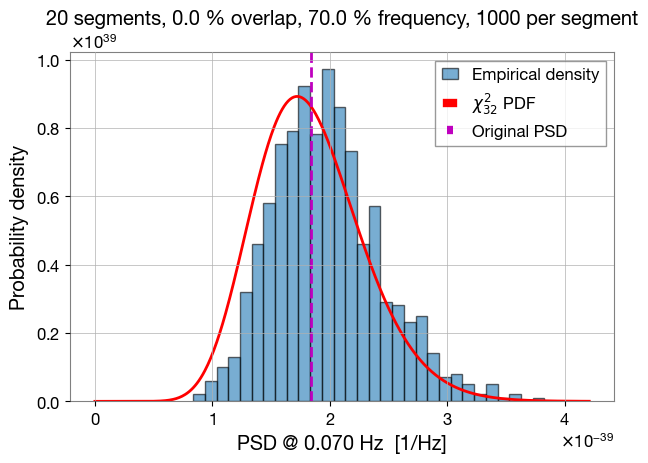

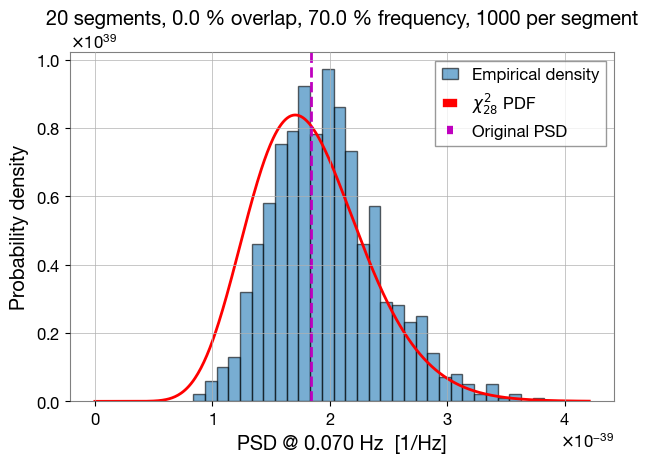

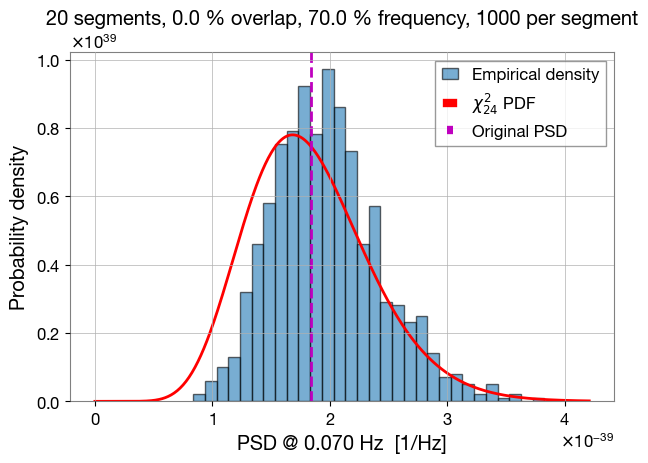

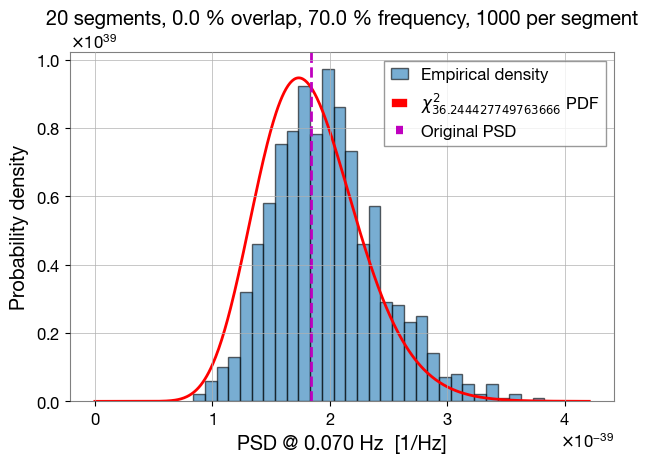

In [71]:
nperseg_noise = 1000
noverlap = 0
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df= 2*nseg
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = noverlap, 
    fraction = 0.7, 
    df = 36
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = noverlap, 
    fraction = 0.7, 
    df = 32
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = noverlap, 
    fraction = 0.7, 
    df = 28
)

psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = noverlap, 
    fraction = 0.7, 
    df = 24
)

df_est = 2 * psd_noise_vals.mean()**2 / psd_noise_vals.var(ddof=1)
psdAndEverything(
    nperseg_noise = nperseg_noise, 
    noverlap = noverlap, 
    fraction = 0.7, 
    df = df_est
)

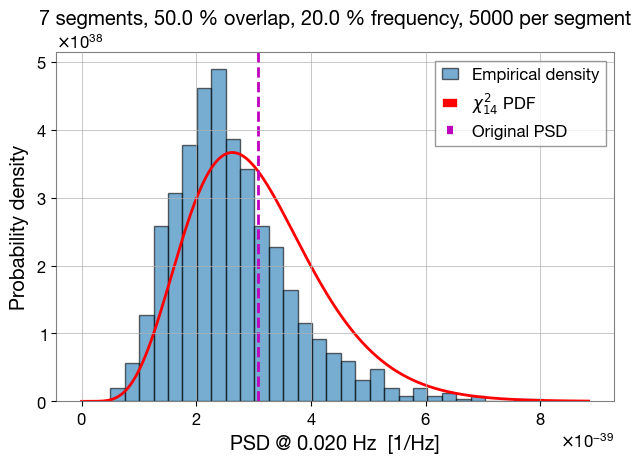

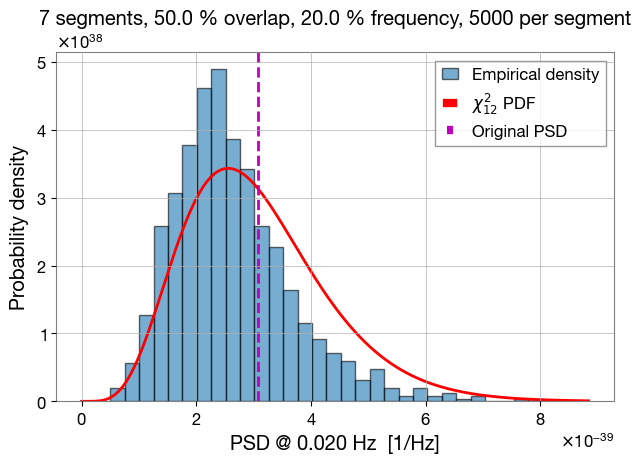

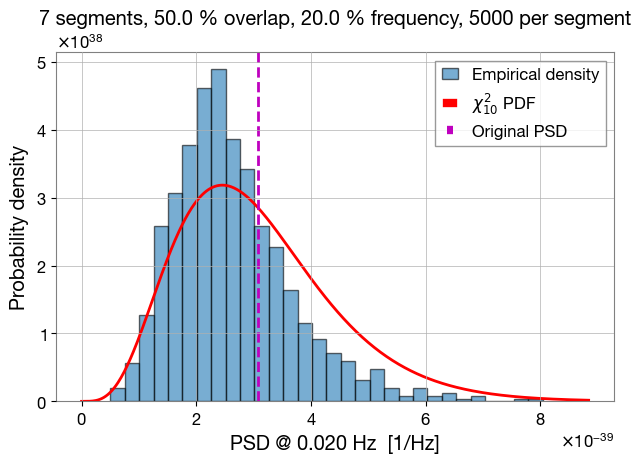

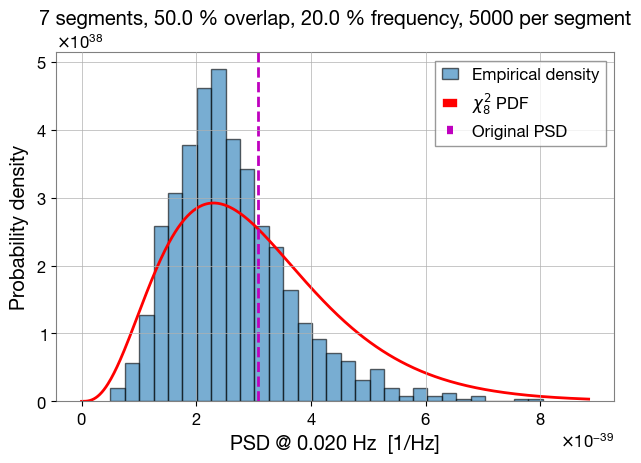

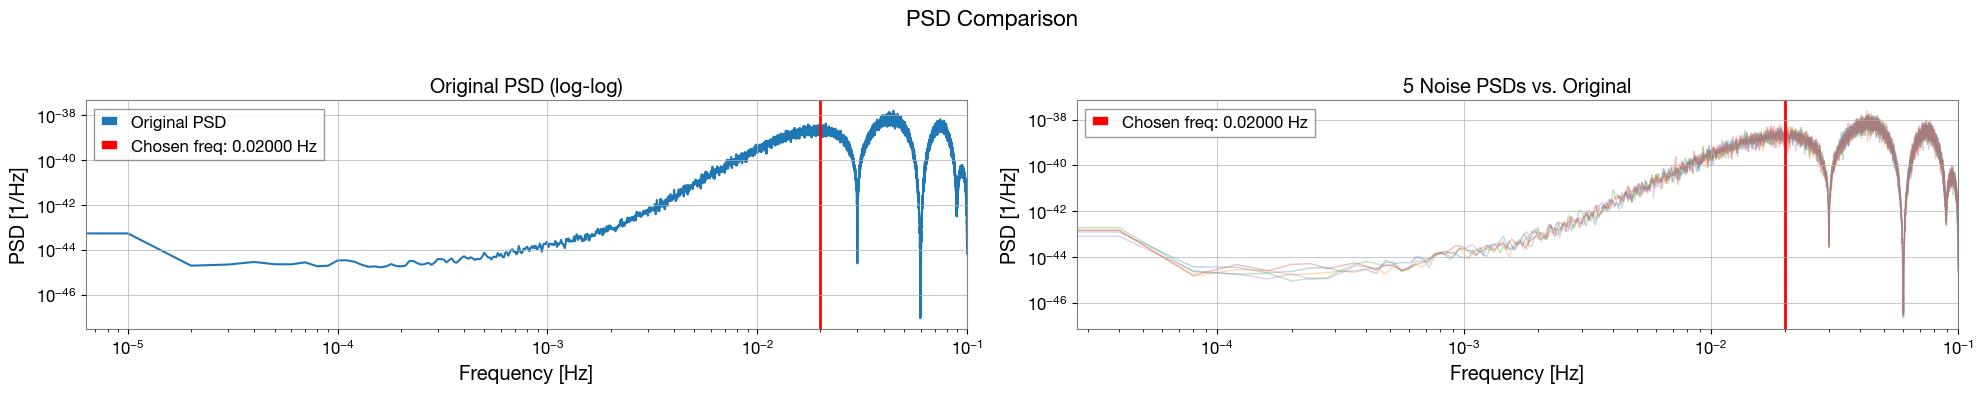

In [74]:
nperseg_noise = 5000
noverlap = nperseg_noise // 2
fraction = 0.2
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=2*nseg
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = fraction, 
    df = 2*nseg - 2
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = fraction, 
    df = 2*nseg - 4
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = nperseg_noise // 2, 
    fraction = fraction, 
    df = 2*nseg - 6
)

plot_orig_and_noise_psds(
    f_orig,
    orig_psd,
    chosen_f_orig,
    f_noise,
    noise_psds,
    chosen_f_noise,
    n=5,
    alpha=0.3,
    bigtitle="PSD Comparison"
)

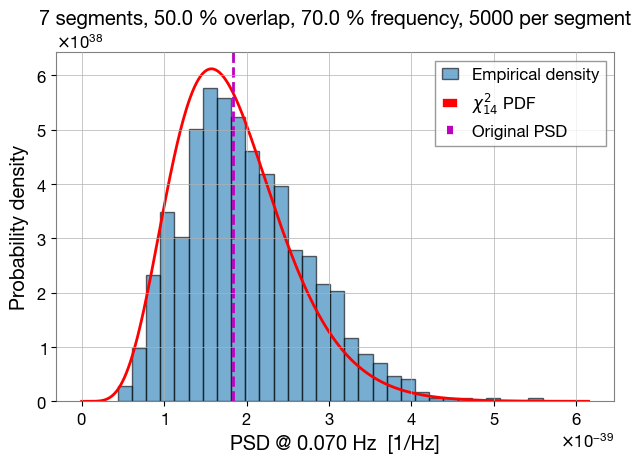

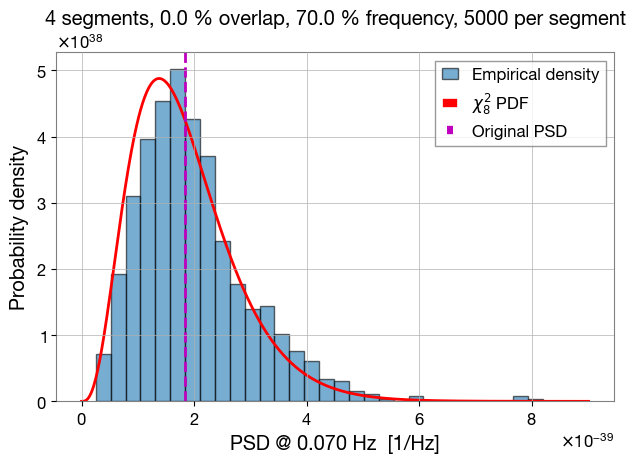

In [75]:
nperseg_noise = 5000
noverlap = nperseg_noise // 2
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=2*nseg
)

nperseg_noise = 5000
noverlap = 0
fraction = 0.7
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=30,  
    df=2*nseg
)

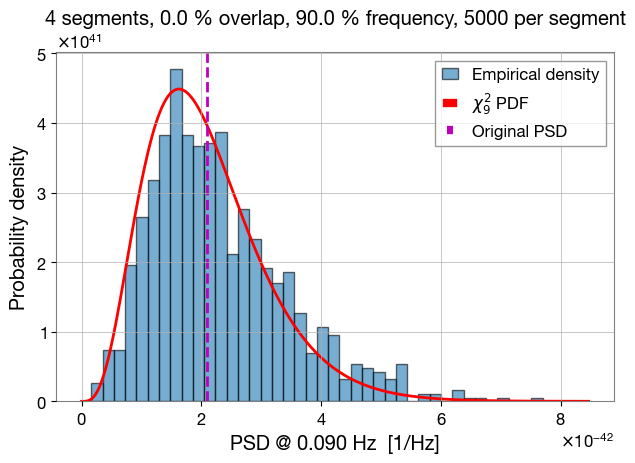

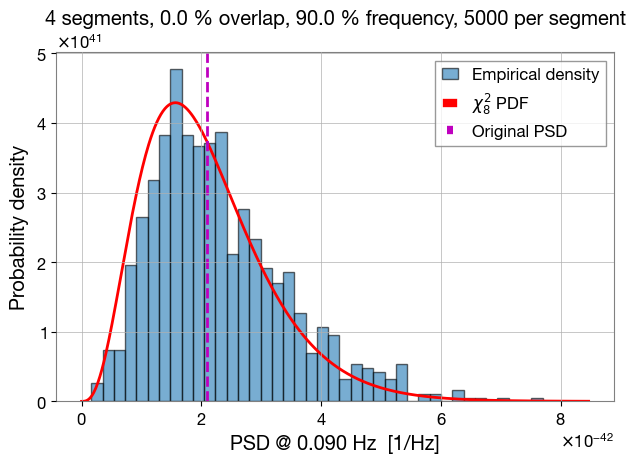

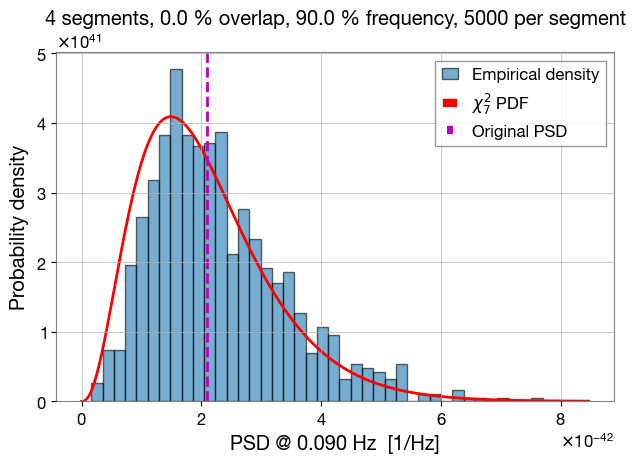

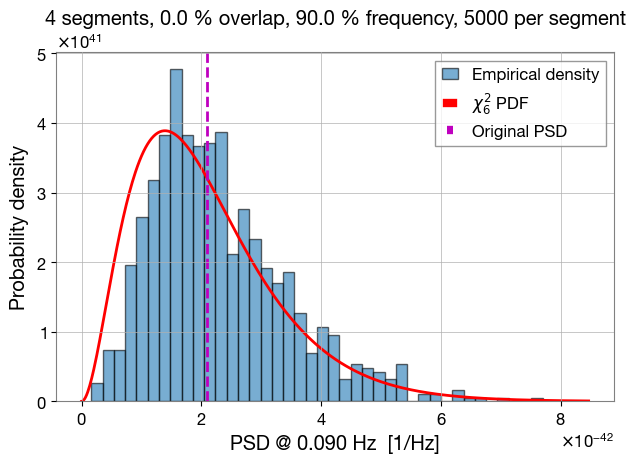

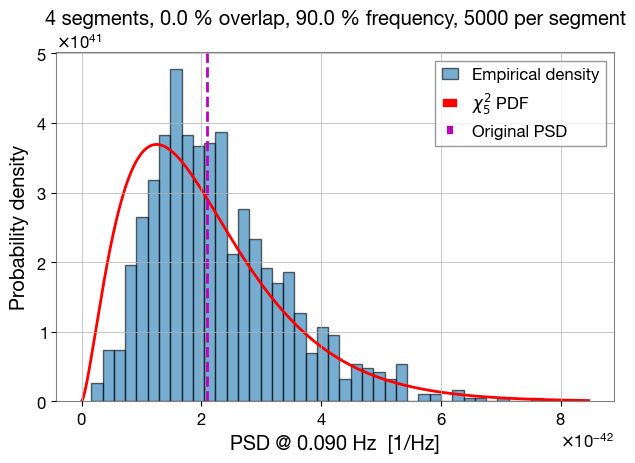

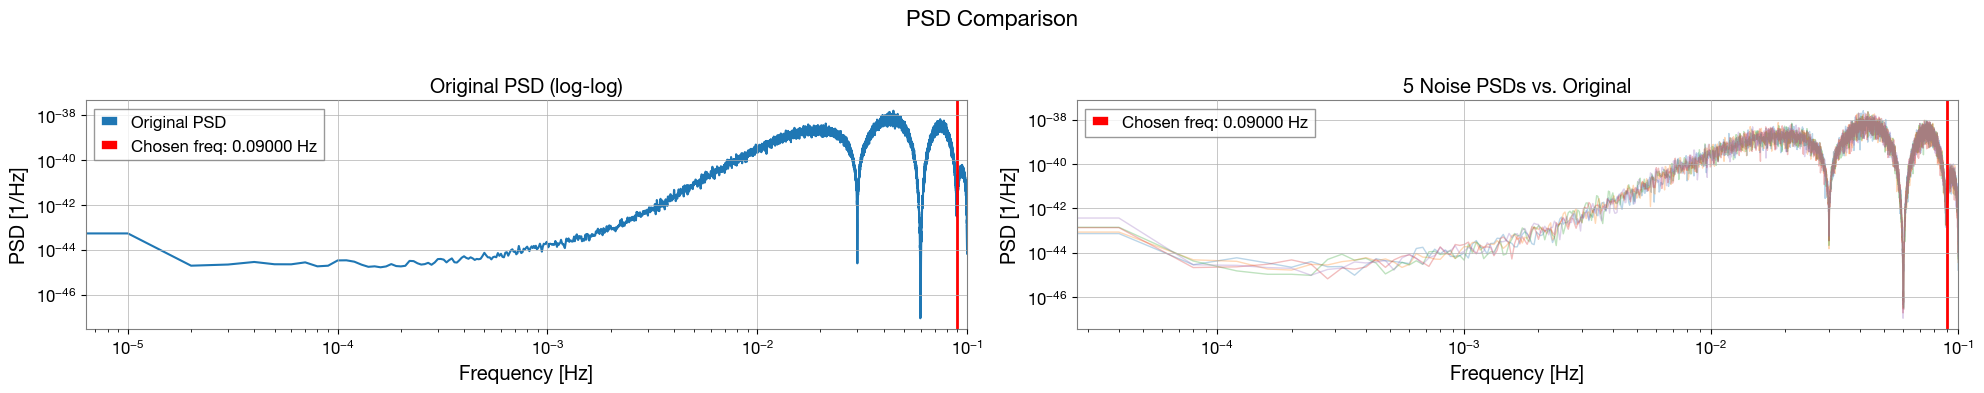

In [76]:
nperseg_noise = 5000
noverlap = 0
fraction = 0.9
f_noise, noise_psds, nseg = n_noise_psds(time_noises, fs, nperseg_noise, noverlap=noverlap)
psd_noise_vals, orig_psd_val, chosen_f_noise, chosen_f_orig = compute_psd_noise_distribution(orig_psd, f_orig, noise_psds, f_noise, fraction = fraction)
plot_psd_noise_histogram(psd_noise_vals, orig_psd_val, chosen_f_noise, title=f"{nseg} segments, {noverlap / nperseg_noise * 100} % overlap, {fraction * 100} % frequency, {nperseg_noise} per segment", 
    n_bins=40,  
    df=9
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = fraction, 
    df = 8,
    n_bins = 40
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = fraction, 
    df = 7,
    n_bins = 40
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = fraction, 
    df = 6,
    n_bins = 40
)

psdAndEverything(
    nperseg_noise = 5000, 
    noverlap = 0, 
    fraction = fraction, 
    df = 5,
    n_bins = 40
)

plot_orig_and_noise_psds(f_orig, orig_psd, chosen_f_orig, f_noise, noise_psds, chosen_f_noise, n=5, alpha=0.3, bigtitle="PSD Comparison")

In [39]:
# Optionally, use estimators 
# df_est, _ = mle_df(psd_noise_vals, mu=orig_psd_val, round_even=False)
# plot_psd_noise_histogram(
#     psd_noise_vals,
#     orig_psd_val,
#     chosen_f_noise,
#     n_bins=30,
#     title="Noise PSD distribution", 
#     df=df_est
# )

# df_est = 2 * psd_noise_vals.mean()**2 / psd_noise_vals.var(ddof=1)
# plot_psd_noise_histogram(
#     psd_noise_vals,
#     orig_psd_val,
#     chosen_f_noise,
#     n_bins=30,
#     title="Noise PSD distribution", 
#     df=df_est
# )

# df_est = int(round((2*psd_noise_vals.mean()**2 / psd_noise_vals.var(ddof=1))/2.0))*2
# plot_psd_noise_histogram(
#     psd_noise_vals,
#     orig_psd_val,
#     chosen_f_noise,
#     n_bins=30,
#     title="Noise PSD distribution", 
#     df=df_est
# )

# Optionally, plot which freq bin you have chosen
# plot_orig_and_noise_psds(
#     f_orig,
#     orig_psd,
#     chosen_f_orig,
#     f_noise,
#     noise_psds,
#     chosen_f_noise,
#     n=5,
#     alpha=0.3,
#     bigtitle="PSD Comparison"
# )